In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/test_data_rna_structure.csv")

print(df.shape)
df.head()

(47962, 19)


,exon,num_DNA_reads,num_exon_inclusion,num_exon_skipping,num_intron_retention,num_splicing_in_exon,num_bad_exon1,num_bad_reads,num_unknown_splicing,total_noncanonical,total,PSI,predicted_PSI,predicted_ss,predicted_mfe,st_predicted_prob,freq_MFE,ensemble_diversity,kl
0,CTCACGTCCAACCCCGGCCGAAGTGGTGTTAGGCCGCAAATTGTAC...,13,83,158,0,0,3,1,10,14,255,0.344398,0.615524,......((((.........))))..((((((.(((((((.(.(.((...,-21.9,0.162405,0.038497,8.80,0.149893
1,CCCTCCTTAACCTCCAAGTGCTTTACTGGCGCTGCCTACAATTCCA...,16,56,15,0,0,0,0,4,4,75,0.788732,0.687822,.....(((((........)))))...((((((.....))))))(((...,-16.5,0.155897,0.025583,19.27,0.025486
2,ACACTCCGCAGCACACTCGGCAAAGAAGTTAGGCCCCGCTCTTACA...,6,0,143,0,0,1,0,3,4,147,0.000000,0.008045,...............(((.((....))))).......((((((((....,-15.3,0.051171,0.056544,9.58,0.008068
3,ACCCACAAAACGCAATTTACACCCAATACCACAGGGGGCGAACATA...,25,9,373,0,0,1,0,14,15,397,0.023560,0.043680,..(((((.............(((......(.(((.........)))...,-9.9,0.065669,0.036062,18.70,0.005786
4,GGTAGTACGCCAATTCGCCGGTGCCGCGAGCCAGAGGCTACCAAAA...,37,328,6,0,2,2,1,11,14,350,0.982036,0.962896,....((((((((((((.......(((((.......))))).........,-20.8,0.214096,0.041650,13.68,0.006299


In [5]:
df[["predicted_mfe", "freq_MFE", "ensemble_diversity", "kl"]].describe()

,predicted_mfe,freq_MFE,ensemble_diversity,kl
count,47962.000000,47962.000000,47962.000000,47962.000000
mean,-16.115657,0.073276,17.339365,0.099904
std,5.103622,0.070663,6.877678,0.228122
min,-42.000000,0.001223,0.870000,0.000000
25%,-19.400000,0.027029,11.990000,0.003590
50%,-15.800000,0.050585,17.110000,0.020299
75%,-12.500000,0.093559,22.410000,0.088034
max,-1.000000,0.885572,40.270000,3.724001


In [7]:
df[["predicted_mfe", "freq_MFE", "ensemble_diversity", "kl"]].info()

<class 'pandas.DataFrame'>
RangeIndex: 47962 entries, 0 to 47961
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   predicted_mfe       47962 non-null  float64
 1   freq_MFE            47962 non-null  float64
 2   ensemble_diversity  47962 non-null  float64
 3   kl                  47962 non-null  float64
dtypes: float64(4)
memory usage: 1.5 MB


In [10]:
df["mfe_bin"] = pd.qcut(df["predicted_mfe"], 3, labels=["low","mid","high"])
df["loss_bin"] = pd.qcut(df["kl"], 3, labels=["low","mid","high"])

In [11]:
cols = [
    "predicted_mfe","kl","exon","predicted_ss",
    "freq_MFE","ensemble_diversity",
    "PSI","predicted_PSI"
]

for m in df["mfe_bin"].cat.categories:
    for l in df["loss_bin"].cat.categories:
        print(f"\n=== {m} MFE | {l} loss ===")
        display(
            df[(df["mfe_bin"]==m) & (df["loss_bin"]==l)]
            .sort_values("kl", ascending=False)
            [cols]
            .head(3)
        )


=== low MFE | low loss ===


,predicted_mfe,kl,exon,predicted_ss,freq_MFE,ensemble_diversity,PSI,predicted_PSI
39388,-20.8,0.007015,CCACCGTTTAGCTCCACGTATCCTGCGTTCAACAGATTAAAACAAA...,((.((.((..(((((((..(((...(((((...)))))....((((...,0.116096,5.39,0.533074,0.591653
7170,-19.1,0.007013,CCACTGGAAAGACCTTAAGGACTCTCTATTCCCATCCAGTCTCTTG...,..(((((......))))).((((((((((((((................,0.159632,11.54,0.990415,0.973962
16346,-22.1,0.007006,AGGTCTTCAAGAACGCATGCCGCTTGTCCTCATAAATGTGGGACCA...,....((((....(((....(((((.((....((((((.(((((......,0.028922,11.80,0.946667,0.915854



=== low MFE | mid loss ===


,predicted_mfe,kl,exon,predicted_ss,freq_MFE,ensemble_diversity,PSI,predicted_PSI
12394,-22.6,0.053291,CGAAAGATCGCCCGGTCCGATAATGCCACCATTATCTAAACAAGGT...,(((((((((.(((..((((....)))).(((((((....)))))))...,0.115310,11.90,1.000000,0.948093
23154,-22.1,0.053261,AGGGCGCGACCAACCAAGCGGGTTGTGACCTGCTCCCAAATTGAAT...,......((((.((......)))))).(((((((....))))))).(...,0.093064,23.69,0.169643,0.071872
40178,-18.8,0.053251,CACCGTATTTTCCACCATAGCCCCGACCTGTTTAAACGTCGCTATC...,...(((((((((.(((..........(((((...(((.(......)...,0.120977,5.20,0.913580,0.793787



=== low MFE | high loss ===


...

,predicted_mfe,kl,exon,predicted_ss,freq_MFE,ensemble_diversity,PSI,predicted_PSI
47113,-9.3,0.007019,AGCAATTGTCCCCATAAAGTATGCGAACCGAACGCATCCTCCATCC...,......((((.((((((..........))).))).))))..........,0.111971,12.56,0.000000,0.007005
3870,-12.4,0.007016,TAGCCCCAATTCCGATACTGAAACGGGCCGACCCTTAATGATCACC...,(((..(((.((.((((...(((.......)))..)))).)).)))....,0.013289,19.23,0.095238,0.133759
23440,-10.9,0.007011,TGCCTCGACATCTTCTACACCCACGTAACTAAAGTCAGCTGTATCC...,..((.(((....))).)).......(((......)))......(((...,0.023324,26.36,0.989474,0.972502



=== high MFE | mid loss ===


,predicted_mfe,kl,exon,predicted_ss,freq_MFE,ensemble_diversity,PSI,predicted_PSI
31185,-10.9,0.053264,TTCACTTCTGATCCTACAGAAATACATGTTTCACAGATAAATAGGC...,....((((........))))........(((((....))))).(((...,0.038152,26.23,0.000000,0.051882
25776,-10.3,0.053228,ACACCGCCTGCTCATCCGAACTGCGATACCCGACACATTAAATCCA...,....(((((......))))).........((((.(((............,0.057148,9.79,1.000000,0.948152
40189,-10.0,0.053171,AACCACACTTACTCCGTCGTATATCGAGACCCGAAACACCAGCAAG...,.............((.((((..((((..((((((((.....))).....,0.048218,13.63,0.993166,0.926097



=== high MFE | high loss ===


,predicted_mfe,kl,exon,predicted_ss,freq_MFE,ensemble_diversity,PSI,predicted_PSI
14677,-10.2,2.430801,GCGACCATCCAGGTAAGCTCCTCTTACTCAATCCAGAGAACTACCG...,.....(((..((.(((.....)))..)).)))....(((......)...,0.029743,23.51,0.000000,0.912035
44393,-11.1,2.078189,CGCGGGCCTCACACGTACACCTACGATACAACAACAAGTTAAAGAT...,............(((((((....((((....))))..............,0.130067,20.34,0.007634,0.882154
9398,-8.7,2.035006,TCACGCCCCCTTCTCTCAAACCCACCTTACATCGATCCATTCTACA...,......(((((................))))).((((.((...((....,0.054643,15.43,0.798658,0.042170


In [12]:
grid = pd.crosstab(df["mfe_bin"], df["loss_bin"])
print(grid)

loss_bin   low   mid  high
mfe_bin                   
low       5500  5060  5474
mid       5353  5570  5357
high      5135  5357  5156


In [14]:
import json

cols = [
    "predicted_mfe", "kl", "exon", "predicted_ss",
    "freq_MFE", "ensemble_diversity",
    "PSI", "predicted_PSI"
]

results = {}

for m in df["mfe_bin"].cat.categories:
    results[str(m)] = {}

    for l in df["loss_bin"].cat.categories:
        subset = (
            df[(df["mfe_bin"] == m) & (df["loss_bin"] == l)]
            .sort_values("kl", ascending=False)[cols]
            .head(3)
        )

        results[str(m)][str(l)] = subset.to_dict(orient="records")

with open("mfe_loss_examples.json", "w") as f:
    json.dump(results, f, indent=2)

print("Saved to mfe_loss_examples.json")

Saved to mfe_loss_examples.json


In [15]:
with open("mfe_loss_examples.json") as f:
    data = json.load(f)

def title_mfe(k):
    return {"low": "Low MFE", "mid": "Mid MFE", "high": "High MFE"}[k]

def title_loss(k):
    return {"low": "Low Loss", "mid": "Mid Loss", "high": "High Loss"}[k]

lines = []

for mfe_key in ["low", "mid", "high"]:
    lines.append(f"### {title_mfe(mfe_key)}")
    for loss_key in ["low", "mid", "high"]:
        lines.append(f"#### {title_loss(loss_key)}")
        for i, rec in enumerate(data[mfe_key][loss_key], start=1):
            ss = rec["predicted_ss"]
            left_ss = ss[:10]
            exon_ss = ss[10:-10]
            right_ss = ss[-10:]

            lines.append(f"- exon {i}")
            lines.append("```")
            lines.append(rec["exon"])
            lines.append(exon_ss)
            lines.append(f"flanks: {left_ss}, {right_ss}")
            lines.append(f"MFE: {rec['predicted_mfe']}")
            lines.append(f"freq_MFE: {rec['freq_MFE']}")
            lines.append(f"ensemble diversity: {rec['ensemble_diversity']}")
            lines.append(f"PSI: {rec['PSI']}")
            lines.append(f"predicted_PSI: {rec['predicted_PSI']}")
            lines.append(f"KL: {rec['kl']}")
            lines.append("```")
            lines.append("")

with open("rna_structure_notes.md", "w") as f:
    f.write("\n".join(lines))

print("Saved to rna_structure_notes.md")

Saved to rna_structure_notes.md


In [16]:
# Inspect the KL distribution

df["kl"].describe(percentiles=[0.5,0.75,0.9,0.95,0.99,0.999])

count    47962.000000
mean         0.099904
std          0.228122
min          0.000000
50%          0.020299
75%          0.088034
90%          0.268215
95%          0.467327
99%          1.130964
99.9%        2.396955
max          3.724001
Name: kl, dtype: float64

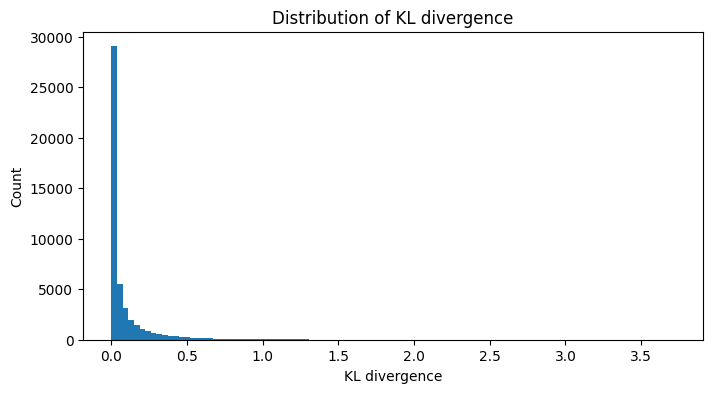

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df["kl"], bins=100)
plt.xlabel("KL divergence")
plt.ylabel("Count")
plt.title("Distribution of KL divergence")
plt.show()

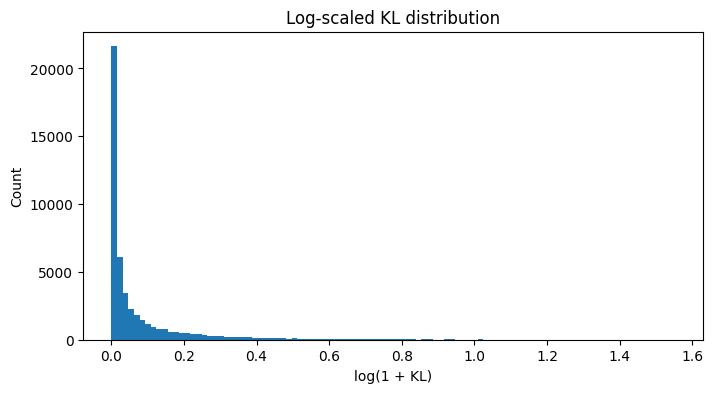

In [18]:
plt.figure(figsize=(8,4))
plt.hist(np.log1p(df["kl"]), bins=100)
plt.xlabel("log(1 + KL)")
plt.ylabel("Count")
plt.title("Log-scaled KL distribution")
plt.show()

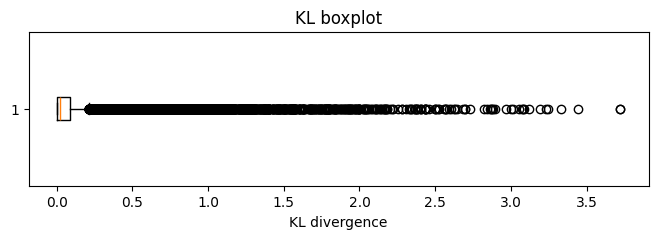

In [19]:
plt.figure(figsize=(8,2))
plt.boxplot(df["kl"], vert=False)
plt.xlabel("KL divergence")
plt.title("KL boxplot")
plt.show()

In [21]:
for t in [0.05,0.1,0.2,0.3,0.4,0.5,1,2,3]:
    pct = (df["kl"] > t).mean()*100
    print(f"KL > {t}: {pct:.2f}%")

KL > 0.05: 34.33%
KL > 0.1: 23.06%
KL > 0.2: 13.48%
KL > 0.3: 8.84%
KL > 0.4: 6.23%
KL > 0.5: 4.52%
KL > 1: 1.32%
KL > 2: 0.20%
KL > 3: 0.03%


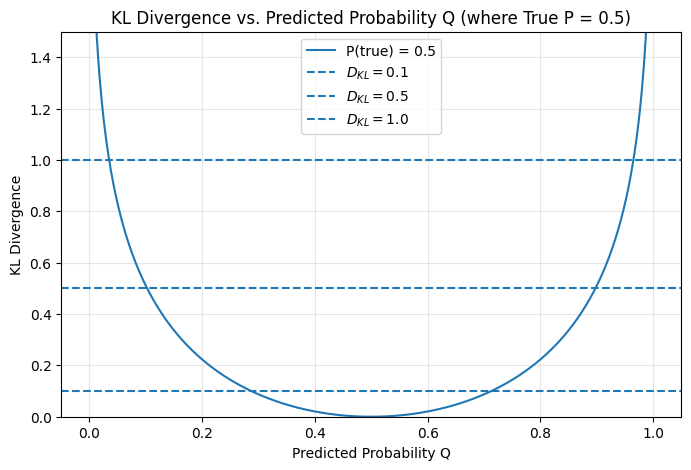

In [22]:
def bernoulli_kl(p, q, eps=1e-8):
    p = np.clip(p, eps, 1 - eps)
    q = np.clip(q, eps, 1 - eps)
    return p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))

q = np.linspace(1e-4, 1 - 1e-4, 1000)

true_p = 0.5
kl = bernoulli_kl(true_p, q)

plt.figure(figsize=(8, 5))
plt.plot(q, kl, label=f"P(true) = {true_p}")

for threshold, color in [(0.1, "green"), (0.5, "orange"), (1.0, "red")]:
    plt.axhline(threshold, linestyle="--", label=f"$D_{{KL}} = {threshold}$")

plt.xlabel("Predicted Probability Q")
plt.ylabel("KL Divergence")
plt.title(f"KL Divergence vs. Predicted Probability Q (where True P = {true_p})")
plt.ylim(0, 1.5)
plt.legend()
plt.grid(alpha=0.3)
plt.show()


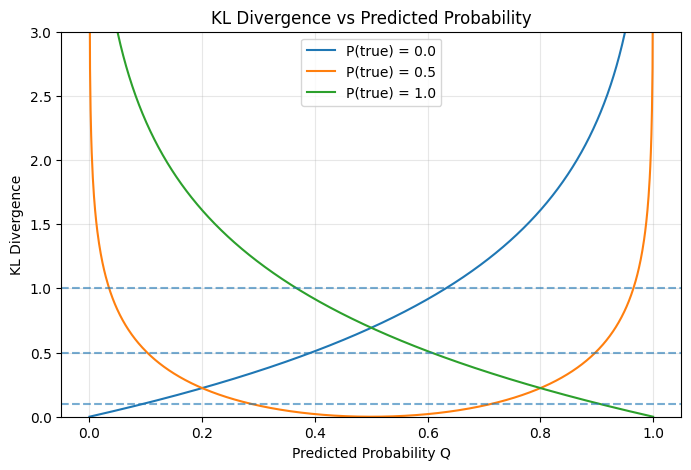

In [23]:
q = np.linspace(1e-4, 1 - 1e-4, 1000)

plt.figure(figsize=(8, 5))

for true_p in [0.0, 0.5, 1.0]:
    kl = bernoulli_kl(true_p, q)
    plt.plot(q, kl, label=f"P(true) = {true_p}")

for threshold in [0.1, 0.5, 1.0]:
    plt.axhline(threshold, linestyle="--", alpha=0.6)

plt.xlabel("Predicted Probability Q")
plt.ylabel("KL Divergence")
plt.title("KL Divergence vs Predicted Probability")
plt.ylim(0, 3)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [25]:
df["num_base_pairs"] = df["predicted_ss"].apply(lambda s: str(s).count("("))
df["paired_nt_fraction"] = 2 * df["num_base_pairs"] / df["predicted_ss"].str.len()

def spearman_manual(a, b):
    ra = pd.Series(a).rank()
    rb = pd.Series(b).rank()
    return ra.corr(rb)

print("Manual Spearman correlations:")
print("num_base_pairs vs predicted_mfe =", spearman_manual(df["num_base_pairs"], df["predicted_mfe"]))
print("num_base_pairs vs kl =", spearman_manual(df["num_base_pairs"], df["kl"]))
print("paired_nt_fraction vs kl =", spearman_manual(df["paired_nt_fraction"], df["kl"]))

Manual Spearman correlations:
num_base_pairs vs predicted_mfe = -0.631193921665698
num_base_pairs vs kl = 0.015351972346658705
paired_nt_fraction vs kl = 0.015351972346658705


In [27]:
import pandas as pd
import numpy as np

# Make sure num_base_pairs exists
df["num_base_pairs"] = df["predicted_ss"].astype(str).str.count(r"\(")

# MFE: more negative = stronger folding
df["mfe_group"] = pd.qcut(
    df["predicted_mfe"],
    3,
    labels=["Strong MFE", "Mid MFE", "Weak MFE"]
)

df["bp_group"] = pd.qcut(
    df["num_base_pairs"],
    3,
    labels=["Low BP", "Mid BP", "High BP"],
    duplicates="drop"
)

# Define catastrophic failure
df["large_kl"] = df["kl"] > 1.0

# 3x3 conditional probability grid
grid = pd.pivot_table(
    df,
    values="large_kl",
    index="mfe_group",
    columns="bp_group",
    aggfunc="mean",
    observed=True
)

# Convert to percentages
grid_percent = grid * 100

grid_percent

bp_group,Low BP,Mid BP,High BP
mfe_group,,,
Strong MFE,2.878074,2.355212,2.918484
Mid MFE,0.927282,0.772822,0.790413
Weak MFE,0.358262,0.380006,0.470810


In [28]:
counts = pd.crosstab(df["mfe_group"], df["bp_group"])
counts

bp_group,Low BP,Mid BP,High BP
mfe_group,,,
Strong MFE,1911,5180,8943
Mid MFE,6147,6211,3922
Weak MFE,11165,3421,1062


In [29]:
combined = grid_percent.round(2).astype(str) + "% (n=" + counts.astype(str) + ")"
combined

bp_group,Low BP,Mid BP,High BP
mfe_group,,,
Strong MFE,2.88% (n=1911),2.36% (n=5180),2.92% (n=8943)
Mid MFE,0.93% (n=6147),0.77% (n=6211),0.79% (n=3922)
Weak MFE,0.36% (n=11165),0.38% (n=3421),0.47% (n=1062)


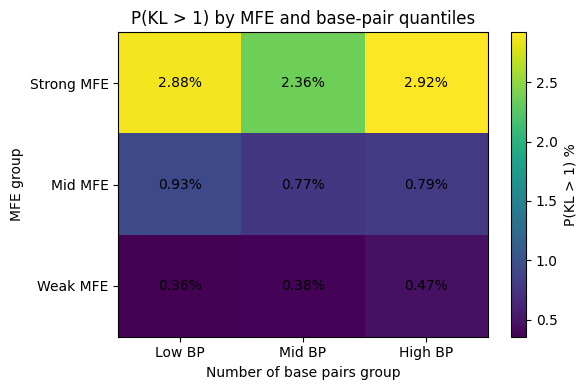

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.imshow(grid_percent, aspect="auto")
plt.colorbar(label="P(KL > 1) %")

plt.xticks(range(len(grid_percent.columns)), grid_percent.columns)
plt.yticks(range(len(grid_percent.index)), grid_percent.index)

plt.xlabel("Number of base pairs group")
plt.ylabel("MFE group")
plt.title("P(KL > 1) by MFE and base-pair quantiles")

for i in range(grid_percent.shape[0]):
    for j in range(grid_percent.shape[1]):
        val = grid_percent.iloc[i, j]
        plt.text(j, i, f"{val:.2f}%", ha="center", va="center")

plt.tight_layout()
plt.show()

diversity_group,Low Diversity,Mid Diversity,High Diversity
mfe_group,,,
Strong MFE,3.149,2.401,2.280
Mid MFE,0.808,0.763,0.929
Weak MFE,0.250,0.480,0.327


diversity_group,Low Diversity,Mid Diversity,High Diversity
mfe_group,,,
Strong MFE,7717,4457,3860
Mid MFE,5075,5501,5704
Weak MFE,3198,6037,6413


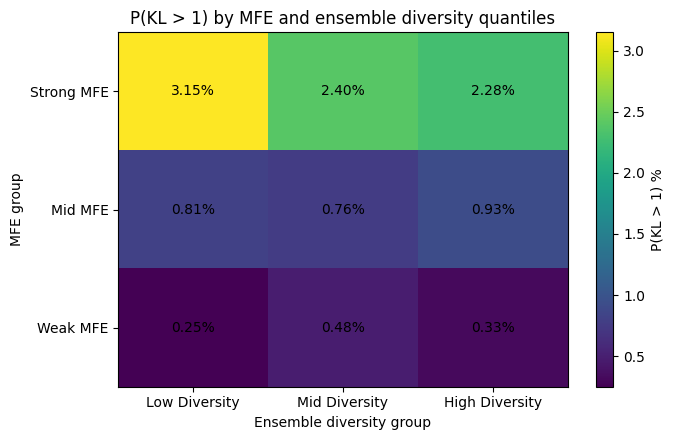

In [31]:
# MFE: more negative = stronger folding
df["mfe_group"] = pd.qcut(
    df["predicted_mfe"],
    3,
    labels=["Strong MFE", "Mid MFE", "Weak MFE"]
)

df["diversity_group"] = pd.qcut(
    df["ensemble_diversity"],
    3,
    labels=["Low Diversity", "Mid Diversity", "High Diversity"],
    duplicates="drop"
)

df["large_kl"] = df["kl"] > 1.0

# Probability grid
grid = pd.pivot_table(
    df,
    values="large_kl",
    index="mfe_group",
    columns="diversity_group",
    aggfunc="mean",
    observed=True
) * 100

# Counts grid
counts = pd.crosstab(df["mfe_group"], df["diversity_group"])

display(grid.round(3))
display(counts)

# Heatmap
plt.figure(figsize=(7, 4.5))
plt.imshow(grid, aspect="auto")
plt.colorbar(label="P(KL > 1) %")

plt.xticks(range(len(grid.columns)), grid.columns)
plt.yticks(range(len(grid.index)), grid.index)

plt.xlabel("Ensemble diversity group")
plt.ylabel("MFE group")
plt.title("P(KL > 1) by MFE and ensemble diversity quantiles")

for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        val = grid.iloc[i, j]
        plt.text(j, i, f"{val:.2f}%", ha="center", va="center")

plt.tight_layout()
plt.show()

In [34]:
import statsmodels.formula.api as smf

# Create binary target
df["high_kl"] = (df["kl"] > 1.0).astype(int)

# Optional: standardize predictors for cleaner coefficients
df["mfe_z"] = (df["predicted_mfe"] - df["predicted_mfe"].mean()) / df["predicted_mfe"].std()
df["div_z"] = (df["ensemble_diversity"] - df["ensemble_diversity"].mean()) / df["ensemble_diversity"].std()

# Logistic regression with interaction
model = smf.logit(
    formula="high_kl ~ mfe_z + div_z + mfe_z:div_z",
    data=df
).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.064630
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                high_kl   No. Observations:                47962
Model:                          Logit   Df Residuals:                    47958
Method:                           MLE   Df Model:                            3
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                 0.07851
Time:                        22:59:59   Log-Likelihood:                -3099.8
converged:                       True   LL-Null:                       -3363.9
Covariance Type:            nonrobust   LLR p-value:                3.640e-114
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept      -4.6939      0.052    -90.262      0.000      -4.796      -4.592
mfe_z          -0.8339    

In [35]:
params = model.params
odds_ratios = np.exp(params)

print("Odds ratios:")
print(odds_ratios)

Odds ratios:
Intercept      0.009151
mfe_z          0.434365
div_z          1.013628
mfe_z:div_z    1.022749
dtype: float64


In [36]:
mfe_vals = np.linspace(df["mfe_z"].min(), df["mfe_z"].max(), 5)
div_vals = np.linspace(df["div_z"].min(), df["div_z"].max(), 5)

grid = pd.DataFrame(
    [(m, d) for m in mfe_vals for d in div_vals],
    columns=["mfe_z", "div_z"]
)

grid["pred_prob_high_kl"] = model.predict(grid)
grid

,mfe_z,div_z,pred_prob_high_kl
0,-5.071759,-2.394611,0.444253
1,-5.071759,-0.962442,0.409043
2,-5.071759,0.469728,0.374743
3,-5.071759,1.901897,0.341656
4,-5.071759,3.334066,0.310041
5,-3.063382,-2.394611,0.118488
6,-3.063382,-0.962442,0.110453
7,-3.063382,0.469728,0.102898
8,-3.063382,1.901897,0.095805
9,-3.063382,3.334066,0.089152


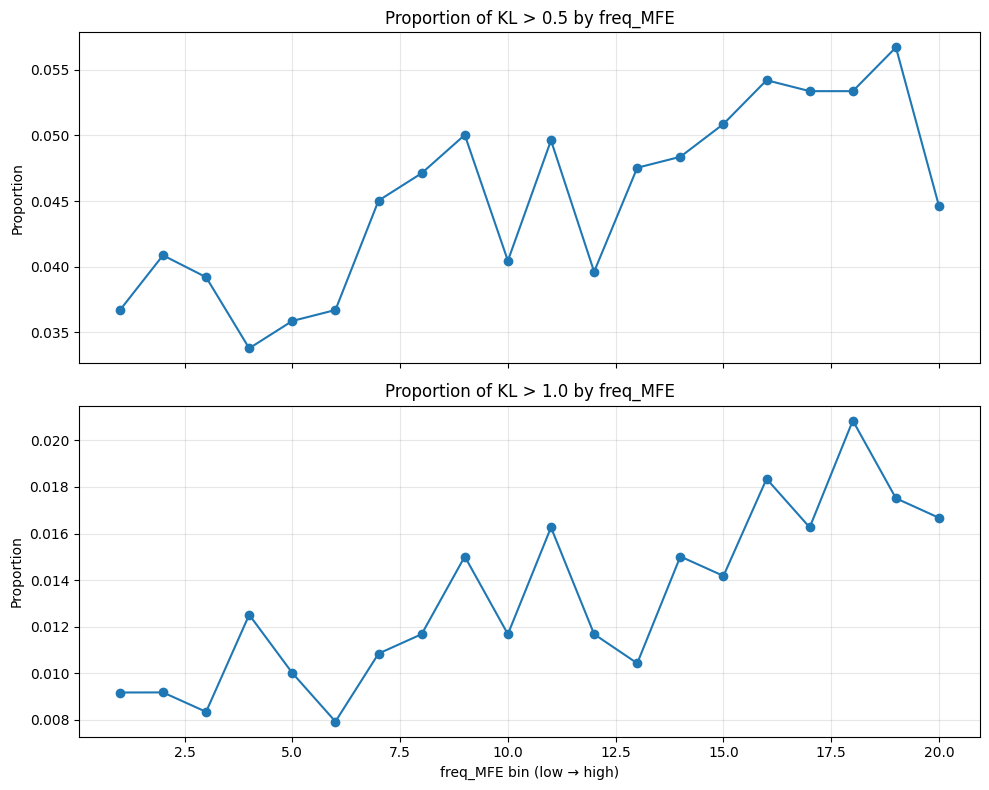

In [38]:
# load data
df = pd.read_csv("../data/test_data_rna_structure.csv")

# thresholds to test
thresholds = [0.5, 1.0]

# make 20 quantile bins of freq_MFE
df["freq_bin"] = pd.qcut(df["freq_MFE"], q=20, labels=False, duplicates="drop") + 1

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for ax, thr in zip(axes, thresholds):
    summary = (
        df.assign(high_kl=(df["kl"] > thr).astype(int))
          .groupby("freq_bin")["high_kl"]
          .mean()
    )

    ax.plot(summary.index, summary.values, marker="o")
    ax.set_title(f"Proportion of KL > {thr} by freq_MFE")
    ax.set_ylabel("Proportion")
    ax.grid(alpha=0.3)

axes[-1].set_xlabel("freq_MFE bin (low → high)")
plt.tight_layout()
plt.show()